In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [3]:
DOMINANCE_FACTOR = 2.0
# MIN_DEPTH_m = 3000.0
# MIN_TILT_km = 5.0

ELLIPSE_FRAC= 1.0
USE_PV_CACHE=True

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
surface = tilt.add_pv_gradient_terms(
    df,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)

surface['dom']='mixed'
surface.loc[surface.topo_plan_ratio_smooth<=-np.log(DOMINANCE_FACTOR),'dom']='plan'
surface.loc[surface.topo_plan_ratio_smooth>= np.log(DOMINANCE_FACTOR),'dom']='topo'


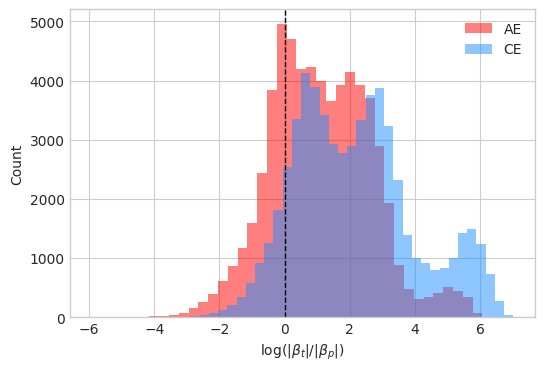

In [5]:
fig,ax=plt.subplots(figsize=(6,4))

for cyc,col in [('AE','red'),('CE','dodgerblue')]:
    surface.loc[surface.Cyc.eq(cyc),'topo_plan_ratio'].hist(
        ax=ax,bins=40,alpha=.5,color=col,label=cyc)

ax.axvline(0,color='k',ls='--',lw=1)
ax.set(xlabel=r'$\log(|\beta_t|/|\beta_p|)$',
       ylabel='Count')
ax.legend(frameon=False)
plt.show()

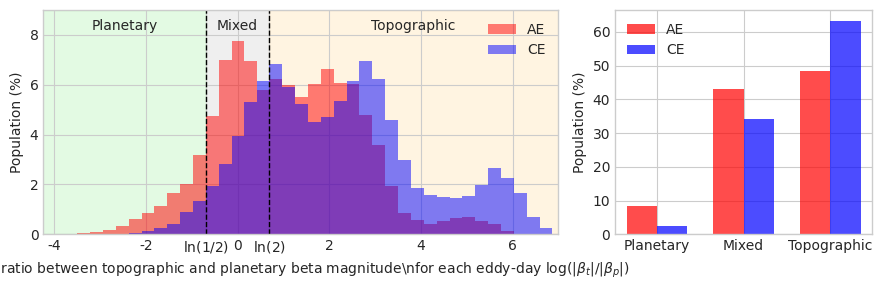

In [30]:
fig,(ax,ax2)=plt.subplots(1,2,figsize=(9,3),gridspec_kw={'width_ratios':[2,1]})

cols={'AE':'red','CE':'blue'}
t=np.log(DOMINANCE_FACTOR)
v=surface.topo_plan_ratio_smooth
bw=(v.max()-v.min())/40
bins=np.unique(np.r_[np.arange(-t,v.min()-bw,-bw)[::-1],
                     np.arange(-t,t,bw),t,
                     np.arange(t,v.max()+bw,bw)])

# Distribution
for cyc in ['AE','CE']:
    x=surface.loc[surface.Cyc.eq(cyc),'topo_plan_ratio_smooth'].dropna()
    ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),
            color=cols[cyc],alpha=.5,label=cyc)

# Dominance regions
ax.axvspan(ax.get_xlim()[0],-t,color='lightgreen',alpha=.25,zorder=0)
ax.axvspan(-t,t,color='lightgrey',alpha=.35,zorder=0)
ax.axvspan(t,ax.get_xlim()[1],color='moccasin',alpha=.4,zorder=0)

ax.axvline(-t,color='k',ls='--',lw=1)
ax.axvline( t,color='k',ls='--',lw=1)
ax.set_ylim(0,9)
ticks=list(ax.get_xticks())+[-np.log(2),np.log(2)]
labels=[f'{x:g}' for x in ax.get_xticks()]+[r'$\ln(1/2)$',r'$\ln(2)$']
ax.set_xticks(ticks,labels)
ax.set_xlim(surface.topo_plan_ratio_smooth.min(), 
                             surface.topo_plan_ratio_smooth.max())

# Region labels
xmin,xmax=ax.get_xlim()
trans=ax.get_xaxis_transform()
ax.text((xmin-t)/2,.96,'Planetary',transform=trans,ha='center',va='top')
ax.text(0,.96,'Mixed',transform=trans,ha='center',va='top')
ax.text((t+xmax)/2,.96,'Topographic',transform=trans,ha='center',va='top')

ax.set(xlabel=r'Log ratio between topographic and planetary beta magnitude\nfor each eddy-day $\log(|\beta_t|/|\beta_p|)$',ylabel='Population (%)')
ax.legend(frameon=False)

# Dominance populations
doms=['plan','mixed','topo']; xx=np.arange(3); w=.35
for i,cyc in enumerate(['AE','CE']):
    d=surface[surface.Cyc.eq(cyc)]
    p=100*d.dom.value_counts(normalize=True).reindex(doms,fill_value=0)
    ax2.bar(xx+(i-.5)*w,p,width=w,color=cols[cyc],label=cyc,alpha=.7)

ax2.set(xticks=xx,xticklabels=['Planetary','Mixed','Topographic'],
        ylabel='Population (%)')
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

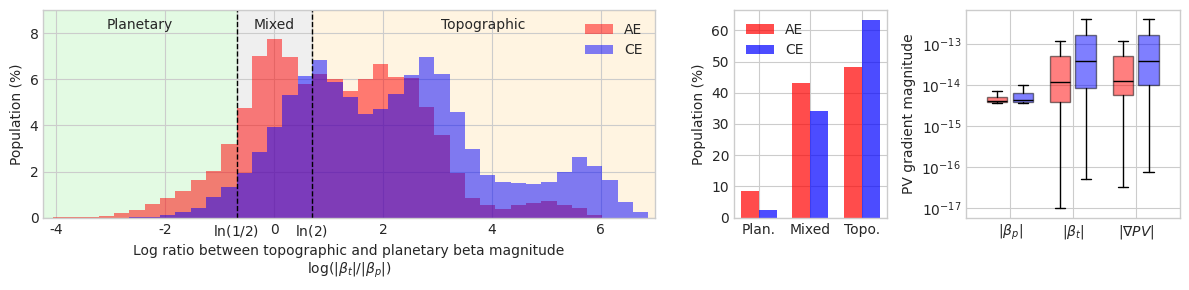

In [39]:
fig,(ax,ax2,ax3)=plt.subplots(1,3,figsize=(12,3),gridspec_kw={'width_ratios':[2,.5,.7]})

cols={'AE':'red','CE':'blue'}
t=np.log(DOMINANCE_FACTOR); v=surface.topo_plan_ratio_smooth
bw=(v.max()-v.min())/40
bins=np.unique(np.r_[np.arange(-t,v.min()-bw,-bw)[::-1],np.arange(-t,t,bw),t,np.arange(t,v.max()+bw,bw)])

# Distribution
for cyc in ['AE','CE']:
    x=surface.loc[surface.Cyc.eq(cyc),'topo_plan_ratio_smooth'].dropna()
    ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),color=cols[cyc],alpha=.5,label=cyc)

ax.axvspan(ax.get_xlim()[0],-t,color='lightgreen',alpha=.25,zorder=0)
ax.axvspan(-t,t,color='lightgrey',alpha=.35,zorder=0)
ax.axvspan(t,ax.get_xlim()[1],color='moccasin',alpha=.4,zorder=0)
ax.axvline(-t,color='k',ls='--',lw=1); ax.axvline(t,color='k',ls='--',lw=1)
ax.set_ylim(0,9)
ticks=list(ax.get_xticks())+[-np.log(2),np.log(2)]
labels=[f'{x:g}' for x in ax.get_xticks()]+[r'$\ln(1/2)$',r'$\ln(2)$']
ax.set_xticks(ticks,labels)
ax.set_xlim(v.min(),v.max())

xmin,xmax=ax.get_xlim(); trans=ax.get_xaxis_transform()
ax.text((xmin-t)/2,.96,'Planetary',transform=trans,ha='center',va='top')
ax.text(0,.96,'Mixed',transform=trans,ha='center',va='top')
ax.text((t+xmax)/2,.96,'Topographic',transform=trans,ha='center',va='top')
ax.set(xlabel=r'Log ratio between topographic and planetary beta magnitude' '\n'
    r'$\log(|\beta_t|/|\beta_p|)$',ylabel='Population (%)')
ax.legend(frameon=False)

# Dominance populations
doms=['plan','mixed','topo']; xx=np.arange(3); w=.35
for i,cyc in enumerate(['AE','CE']):
    d=surface[surface.Cyc.eq(cyc)]
    p=100*d.dom.value_counts(normalize=True).reindex(doms,fill_value=0)
    ax2.bar(xx+(i-.5)*w,p,width=w,color=cols[cyc],alpha=.7,label=cyc)
ax2.set(xticks=xx,xticklabels=['Plan.','Mixed','Topo.'],ylabel='Population (%)')
ax2.legend(frameon=False)

# PV-gradient magnitudes
vars=['PV_grad_plan_mag','PV_grad_topo_mag','PV_grad_mag']
centres=np.arange(3); off=.2
pos=np.ravel(np.column_stack((centres-off,centres+off)))
data=[surface.loc[surface.Cyc.eq(c),var].dropna() for var in vars for c in ['AE','CE']]

bp=ax3.boxplot(data,positions=pos,widths=.32,patch_artist=True,showfliers=False)
for patch,c in zip(bp['boxes'],['AE','CE']*3):
    patch.set_facecolor(cols[c]); patch.set_alpha(.5)
for med in bp['medians']: med.set_color('k')

ax3.set_xticks(centres,[r'$|\beta_p|$',r'$|\beta_t|$',r'$|\nabla PV|$'])
ax3.set_ylabel(r'PV gradient magnitude')
ax3.set_yscale('log')

plt.tight_layout()
plt.show()